# 03. Preprocessing and Principal Component Analysis

## Project Overview

This notebook prepares the customer behavioral feature matrix for
distance-based unsupervised learning.

The analysis will:

1. Define the final modeling feature set.
2. Apply Log1p and Yeo-Johnson transformations to normalize skewed features prior to scaling.
3. Compare StandardScaler and RobustScaler.
4. Examine the resulting feature distributions.
5. Apply PCA for dimensionality reduction.
6. Analyze explained variance and component loadings.
7. Visualize customers in principal-component space.

The objective is to determine which feature representation provides a
suitable foundation for customer segmentation.

### Environment & Module Setup

Import core libraries, set global visualization themes, and load custom project modules for pipeline execution.

In [1]:
import joblib
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from sklearn.decomposition import PCA

from src.data_loader import load_raw_data
from src.cleaning import clean_raw_data
from src.feature_engineering import build_behavioral_features
from src.preprocessing import build_preprocessing_pipeline

### Load and Validate Customer Features

We reconstruct the customer-level behavioral dataset using the project's established data-processing pipeline.

Before preprocessing, we verify the number of customers, engineered features, missing values, data types, and descriptive statistics to ensure the feature matrix is ready for unsupervised learning.

In [2]:
raw_df = load_raw_data('../data/raw/online_retail_II.csv')
df_clean, canceled_df = clean_raw_data(raw_df)
customer_df = build_behavioral_features(df_clean, canceled_df)

print(f'Total Customers Analyzed : {customer_df.shape[0]:,}')
print(f'Features Engineered      : {customer_df.shape[1]}')
print(f'Missing Values Count     : {customer_df.isnull().sum().sum()}','\n',"-" * 50)

customer_df.info()
display(customer_df.sample(5, random_state=42))
customer_df.describe().T

Total Customers Analyzed : 5,878
Features Engineered      : 12
Missing Values Count     : 0 
 --------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer ID           5878 non-null   str    
 1   Monetary              5878 non-null   float64
 2   Frequency             5878 non-null   int64  
 3   TotalItemsPurchased   5878 non-null   int64  
 4   UniqueProducts        5878 non-null   int64  
 5   Recency               5878 non-null   float64
 6   CustomerLifetime      5878 non-null   float64
 7   AverageOrderValue     5878 non-null   float64
 8   AverageItemsPerOrder  5878 non-null   float64
 9   PurchaseRate          5878 non-null   float64
 10  WeekendPurchaseRatio  5878 non-null   float64
 11  CancellationRate      5878 non-null   float64
dtypes: float64(8), int64(3), str(1)
memory u

,Customer ID,Monetary,Frequency,TotalItemsPurchased,UniqueProducts,Recency,CustomerLifetime,AverageOrderValue,AverageItemsPerOrder,PurchaseRate,WeekendPurchaseRatio,CancellationRate
5369,17777,647.56,3,501,141,25.033333,75.893750,215.853333,167.000000,0.026010,0.000000,0.000000
4329,16719,3513.62,14,2356,204,15.140972,711.936111,250.972857,168.285714,0.018234,0.142857,0.176471
199,12546,1161.50,2,633,59,47.028472,31.100694,580.750000,316.500000,0.031152,0.000000,0.333333
5083,17484,209.57,2,339,14,576.881250,47.975000,104.785000,169.500000,0.020419,0.000000,0.000000
4810,17207,292.62,1,233,55,652.737500,0.000000,292.620000,233.000000,0.000000,0.000000,0.000000


,count,mean,std,min,25%,50%,75%,max
Monetary,5878.0,2955.904095,14440.852688,2.95,342.280000,867.740000,2248.305000,580987.040000
Frequency,5878.0,6.289384,13.009406,1.00,1.000000,3.000000,7.000000,398.000000
TotalItemsPurchased,5878.0,1788.695475,8876.297196,1.00,187.000000,480.000000,1350.000000,367193.000000
UniqueProducts,5878.0,81.989112,116.484552,1.00,19.000000,45.000000,103.000000,2550.000000
Recency,5878.0,201.854173,209.351071,1.00,26.054688,96.035417,380.100868,739.121528
CustomerLifetime,5878.0,273.390581,258.962153,0.00,0.000000,221.032292,511.946007,738.101389
AverageOrderValue,5878.0,385.180841,1214.286459,2.95,176.682500,279.242679,414.902458,84236.250000
AverageItemsPerOrder,5878.0,247.556853,1424.480958,1.00,91.000000,153.583333,256.926136,87167.000000
PurchaseRate,5878.0,0.030556,0.134925,0.00,0.000000,0.008899,0.019653,2.688574
WeekendPurchaseRatio,5878.0,0.139740,0.263797,0.00,0.000000,0.000000,0.166667,1.000000


### Define the Feature Transformation Strategy

The engineered features have different distributional characteristics and therefore require different preprocessing strategies.

- **Highly skewed features:** Apply `log1p` to reduce the influence of extreme values.
- **PurchaseRate:** Apply the selected power transformation to reduce its strong right skew.
- **Bounded ratio features:** Preserve their natural range before scaling.
- **Recency and CustomerLifetime:** Apply scaling without logarithmic transformation.

This feature-specific strategy aims to produce a more balanced representation for distance-based algorithms.

In [3]:
skewed_cols = [
    "Monetary",
    "Frequency",
    "TotalItemsPurchased",
    "UniqueProducts",
    "AverageOrderValue",
    "AverageItemsPerOrder"
]

powerd_transform_cols = ['PurchaseRate']

bounded_cols = ["WeekendPurchaseRatio", "CancellationRate"]

standard_cols = ["Recency", "CustomerLifetime"]


feature_names = skewed_cols + powerd_transform_cols + bounded_cols + standard_cols

### Separate Modeling Features from Customer Identifier

`Customer ID` is an identifier rather than a behavioral feature, so it must not influence customer similarity or clustering.

In [4]:
X = customer_df.set_index("Customer ID")

### Compare StandardScaler and RobustScaler

Because the customer features contain substantial variation and potential extreme observations, we evaluate two scaling strategies:

- **StandardScaler:** Centers features at zero and scales them to unit standard deviation.
- **RobustScaler:** Centers features using the median and scales them according to the interquartile range (IQR), making it less sensitive to extreme values.

Both pipelines use the same feature transformations so that the comparison isolates the effect of the scaling method.

In [5]:
preprocessor_standard = build_preprocessing_pipeline(
    skewed_cols=skewed_cols,
    powerd_transform_cols=powerd_transform_cols,
    bounded_cols=bounded_cols,
    standard_cols=standard_cols,
    scaler_type="standard"
)

preprocessor_robust = build_preprocessing_pipeline(
    skewed_cols=skewed_cols,
    powerd_transform_cols=powerd_transform_cols,
    bounded_cols=bounded_cols,
    standard_cols=standard_cols,
    scaler_type="robust"
)

X_standard = preprocessor_standard.fit_transform(X)
X_robust = preprocessor_robust.fit_transform(X)

X_standard.columns = X_robust.columns = feature_names


### Scaling Effect on Feature Statistics

We compare the original feature statistics with the transformed representations to verify that the preprocessing pipelines correctly normalize the feature scales.

For StandardScaler, we expect approximately **mean = 0** and **standard deviation = 1**. For RobustScaler, we expect approximately **median = 0** and **IQR = 1**.

This ensures that no feature dominates distance calculations simply because it has a larger numerical scale.

In [6]:
comparison = pd.DataFrame({
    "Original Mean": X.mean(),
    "Original Std": X.std(),
    "Standard Mean": X_standard.mean(),
    "Standard Std": X_standard.std(),
    "Robust Median": X_robust.median(),
    "Robust IQR": X_robust.quantile(0.75) - X_robust.quantile(0.25),
})

comparison.round(3)

,Original Mean,Original Std,Standard Mean,Standard Std,Robust Median,Robust IQR
AverageItemsPerOrder,247.557,1424.481,-0.0,1.0,0.0,1.0
AverageOrderValue,385.181,1214.286,0.0,1.0,0.0,1.0
CancellationRate,0.118,0.165,-0.0,1.0,0.0,1.0
CustomerLifetime,273.391,258.962,0.0,1.0,0.0,1.0
Frequency,6.289,13.009,0.0,1.0,0.0,1.0
Monetary,2955.904,14440.853,0.0,1.0,0.0,1.0
PurchaseRate,0.031,0.135,-0.0,1.0,0.0,1.0
Recency,201.854,209.351,0.0,1.0,0.0,1.0
TotalItemsPurchased,1788.695,8876.297,-0.0,1.0,0.0,1.0
UniqueProducts,81.989,116.485,-0.0,1.0,0.0,1.0


### Skewness After Preprocessing

**Scaling changes the scale of a feature but does not fundamentally remove its skewness**. Therefore, this comparison verifies whether the transformations applied before scaling successfully reduced the original feature asymmetry.

A substantial reduction in skewness indicates that the preprocessing strategy has produced a more balanced feature distribution for subsequent clustering.

In [7]:
skew_comparison = pd.DataFrame({
    "Original": X.skew(),
    "Standard Pipeline": X_standard.skew(),
    "Robust Pipeline": X_robust.skew(),
})

skew_comparison.round(3)

,Original,Standard Pipeline,Robust Pipeline
AverageItemsPerOrder,47.907,-0.629,-0.629
AverageOrderValue,57.133,0.063,0.063
CancellationRate,1.262,1.262,1.262
CustomerLifetime,0.388,0.388,0.388
Frequency,12.640,1.001,1.001
Monetary,25.070,0.269,0.269
PurchaseRate,9.858,1.063,1.063
Recency,0.887,0.887,0.887
TotalItemsPurchased,21.855,-0.095,-0.095
UniqueProducts,6.224,-0.281,-0.281


### Distribution Comparison Across Key Behavioral Features

The plots show how the selected logarithmic transformations and scaling methods affect the distributions of **Monetary, Frequency, TotalItemsPurchased, and AverageOrderValue**.

The goal is not to force every feature into a perfectly normal distribution, but to obtain a representation where extreme values have less disproportionate influence on distance-based clustering.

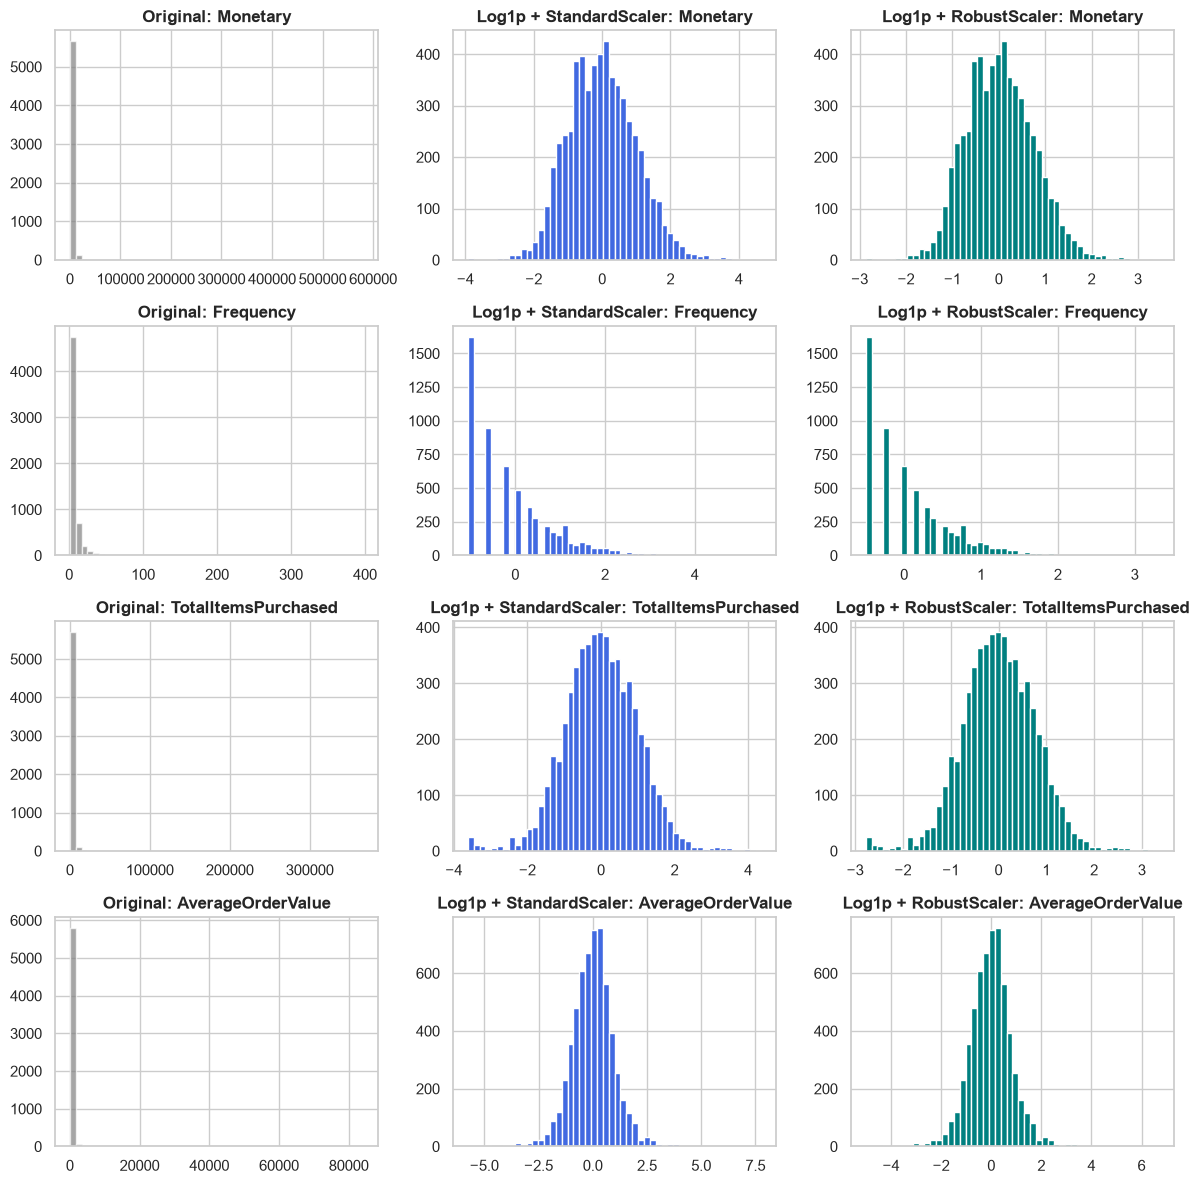

In [8]:
features = [
    "Monetary",
    "Frequency",
    "TotalItemsPurchased",
    "AverageOrderValue",
]

fig, axes = plt.subplots(len(features), 3, figsize=(12, 12))

for i, feature in enumerate(features):
    axes[i, 0].hist(X[feature], bins=50, color="gray", alpha=0.7)
    axes[i, 0].set_title(f"Original: {feature}", fontweight="bold")

    axes[i, 1].hist(X_standard[feature], bins=50, color="royalblue")
    axes[i, 1].set_title(f"Log1p + StandardScaler: {feature}", fontweight="bold")

    axes[i, 2].hist(X_robust[feature], bins=50, color="teal")
    axes[i, 2].set_title(f"Log1p + RobustScaler: {feature}", fontweight="bold")

plt.tight_layout()
plt.show()

### Outlier Assessment After Scaling

Boxplots provide a final visual check of the feature distributions and remaining extreme observations after preprocessing.

**Outliers are not automatically removed because extreme customer behavior may represent genuine high-value or highly active customers. Instead, we assess whether the chosen transformations and scaling strategy sufficiently limit their influence on subsequent distance-based algorithms**.

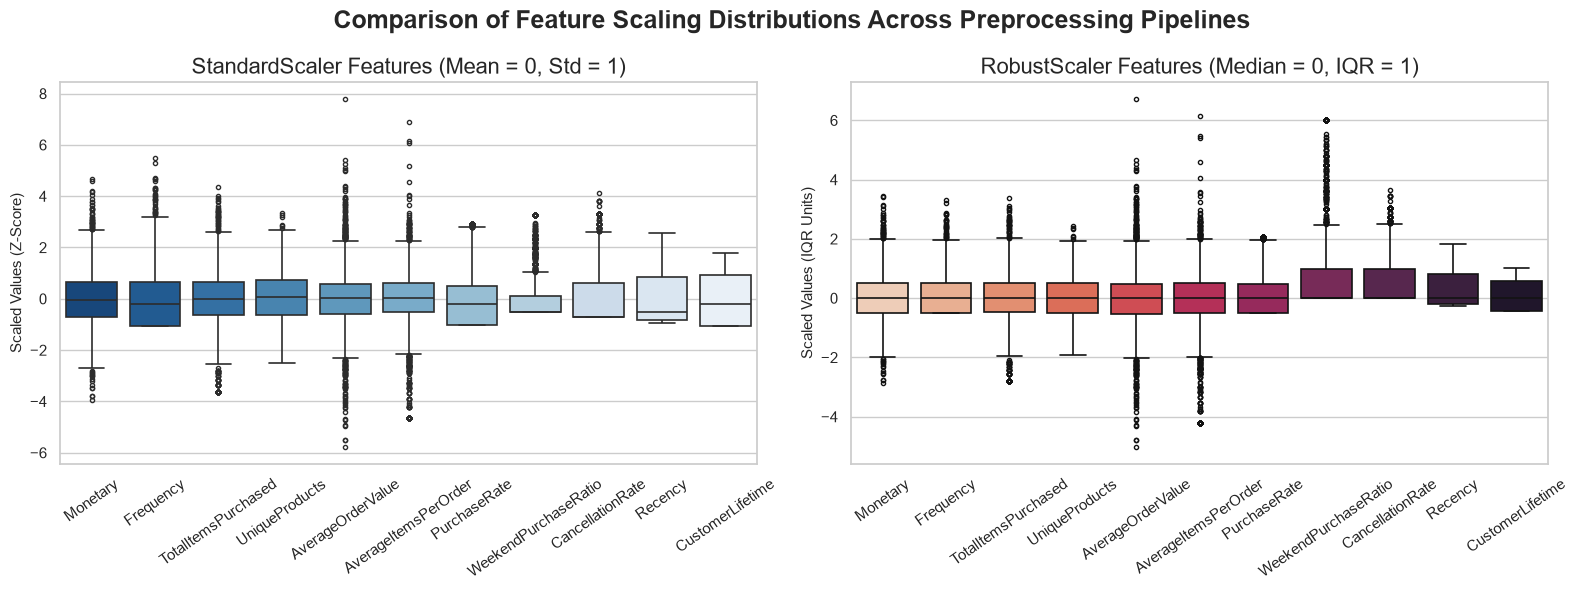

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=X_standard, 
    ax=axes[0], 
    palette="Blues_r", 
    fliersize=3, 
    linewidth=1.2
)
axes[0].set_title('StandardScaler Features (Mean = 0, Std = 1)', fontsize=16)
axes[0].set_ylabel('Scaled Values (Z-Score)', fontsize=11)
axes[0].tick_params(axis="x", rotation=35)

sns.boxplot(
    data=X_robust, 
    ax=axes[1], 
    palette='rocket_r', 
    fliersize=3, 
    linewidth=1.2
)
axes[1].set_title("RobustScaler Features (Median = 0, IQR = 1)", fontsize=16)
axes[1].set_ylabel("Scaled Values (IQR Units)", fontsize=11)
axes[1].tick_params(axis='x', rotation=35)

fig.suptitle('Comparison of Feature Scaling Distributions Across Preprocessing Pipelines', fontsize=18, fontweight="bold")

plt.tight_layout()
plt.show()

> Both preprocessing strategies successfully place the behavioral variables on comparable scales. StandardScaler standardizes features using their means and standard deviations, whereas RobustScaler relies on the median and IQR and is consequently less influenced by extreme customer behavior. **The final scaler will not be selected from distribution plots alone; both representations will be evaluated further through PCA and downstream clustering performance.**

### Principal Component Analysis (PCA)

After preprocessing, the customer features are on comparable scales and are suitable for distance-based methods.

However, the feature matrix still contains correlated behavioral signals. PCA can transform these correlated features into a smaller set of orthogonal principal components while preserving as much variance as possible.

In this section, PCA will be used for two purposes:

1. Understand the structure and redundancy of the customer feature space.
2. Determine whether a lower-dimensional representation is appropriate for downstream clustering.

**PCA will be evaluated separately for the StandardScaler and RobustScaler preprocessing strategies.**

PCA will not automatically replace the original scaled feature space. The final representation will be selected based on **explained variance, PCA loadings, visualization, and suitability for clustering.**

In [10]:
pca_standard_full = PCA()
X_standard_pca_full = pca_standard_full.fit_transform(X_standard)

pca_robust_full = PCA()
X_robust_pca_full = pca_robust_full.fit_transform(X_robust)

### Explained Variance

Each principal component captures a portion of the total variance in the dataset.

The explained variance ratio tells us how much information, measured as variance, is captured by each component.

The cumulative explained variance shows how much variance is retained when multiple components are combined.

This helps us determine how many components may provide a useful lower-dimensional representation.

In [11]:
standard_explained = pca_standard_full.explained_variance_ratio_
robust_explained = pca_robust_full.explained_variance_ratio_

standard_cumulative = standard_explained.cumsum()
robust_cumulative = robust_explained.cumsum()

variance_comparison = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(standard_explained))],
    "Standard Explained": standard_explained,
    "Standard Cumulative": standard_cumulative,
    "Robust Explained": robust_explained,
    "Robust Cumulative": robust_cumulative
})

variance_comparison

,Principal Component,Standard Explained,Standard Cumulative,Robust Explained,Robust Cumulative
0,PC1,0.485133,0.485133,0.366081,0.366081
1,PC2,0.144768,0.629901,0.325835,0.691916
2,PC3,0.094987,0.724888,0.116586,0.808502
3,PC4,0.085399,0.810287,0.070776,0.879278
4,PC5,0.076050,0.886337,0.042369,0.921646
5,PC6,0.049724,0.936061,0.027335,0.948982
6,PC7,0.031463,0.967525,0.026428,0.975410
7,PC8,0.024716,0.992241,0.020948,0.996357
8,PC9,0.007485,0.999726,0.003457,0.999814
9,PC10,0.000272,0.999998,0.000184,0.999998


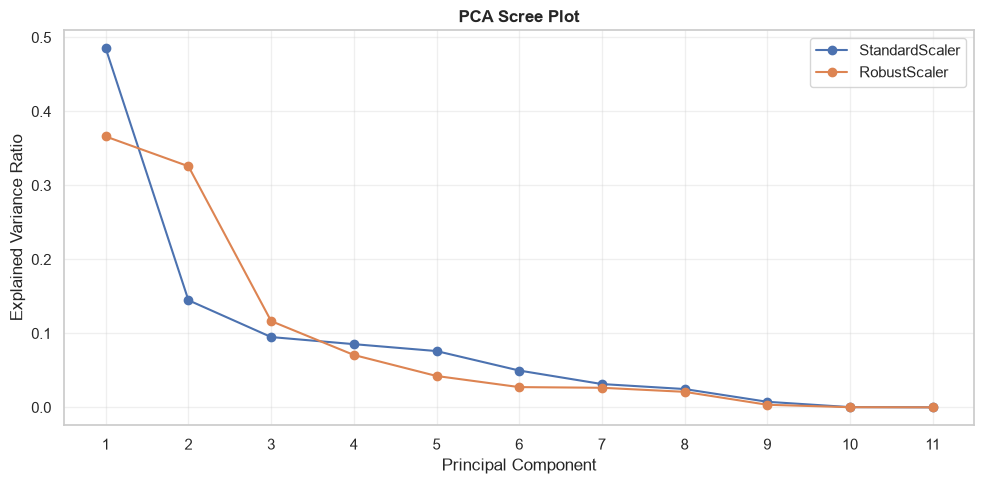

In [12]:
components = np.arange(1, len(standard_explained) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    components,
    standard_explained,
    marker="o",
    label="StandardScaler"
)

plt.plot(
    components,
    robust_explained,
    marker="o",
    label="RobustScaler"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot", fontweight='bold')
plt.xticks(components)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

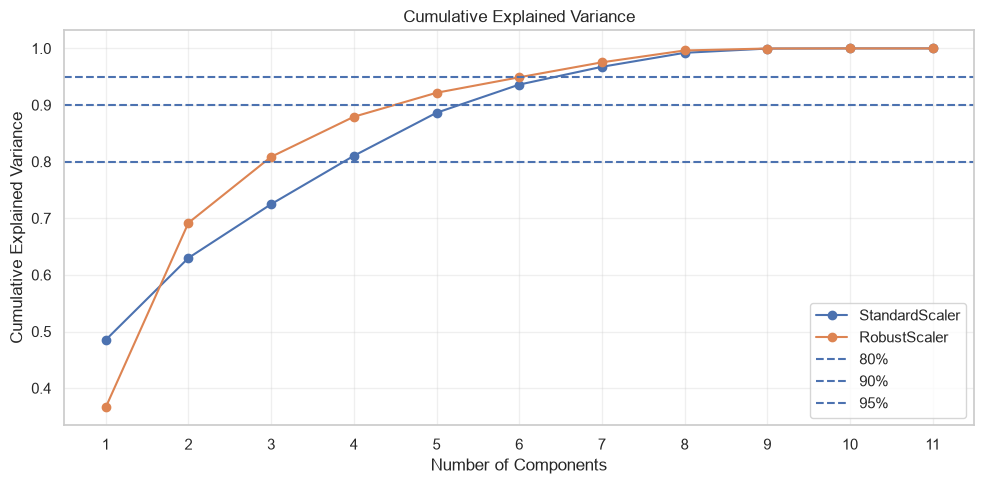

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    components,
    standard_cumulative,
    marker="o",
    label="StandardScaler"
)

plt.plot(
    components,
    robust_cumulative,
    marker="o",
    label="RobustScaler"
)

plt.axhline(
    0.80,
    linestyle="--",
    label="80%"
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90%"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95%"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.xticks(components)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

### PCA Dimensionality Decision

The original modeling space contains 11 behavioral features.

The cumulative explained-variance analysis shows that:

- StandardScaler PCA requires 4 components to retain approximately 80% of the variance and 6 components to retain more than 90%.
- RobustScaler PCA requires only 3 components to retain approximately 80% and 5 components to retain more than 90%.
- Both preprocessing strategies require 7 components to retain approximately 95% of the variance.

Therefore, PCA provides meaningful dimensionality reduction, particularly around the 80–90% variance range. For clustering experiments, moderate-dimensional PCA representations such as 3–6 components are more interesting candidates than automatically retaining enough components for 95% variance.

In [14]:
thresholds = [0.80, 0.90, 0.95]

component_summary = pd.DataFrame({
    "Variance Threshold": thresholds,
    "Standard PCA": [
        np.argmax(standard_cumulative >= t) + 1
        for t in thresholds
    ],
    "Robust PCA": [
        np.argmax(robust_cumulative >= t) + 1
        for t in thresholds
    ],
})

component_summary

,Variance Threshold,Standard PCA,Robust PCA
0,0.80,4,3
1,0.90,6,5
2,0.95,7,7


### PCA Loadings

The principal components are linear combinations of the original behavioral features.

PCA loadings indicate the contribution of each original feature to each principal component.

Examining the loadings helps us understand whether the principal components represent meaningful behavioral dimensions such as customer value, purchasing activity, engagement, or cancellation behavior.

In [15]:
standard_loadings = pd.DataFrame(
    pca_standard_full.components_.T,
    index=feature_names,
    columns=[
        f"PC{i}"
        for i in range(1, pca_standard_full.n_components_ + 1)
    ]
)

standard_loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
Monetary,0.419410,0.039598,-0.021274,0.040050,0.072289,0.101278,-0.263385,0.261793,-0.200913,-0.534722,-0.583769
Frequency,0.371831,-0.343737,-0.063312,0.043855,0.088467,0.198789,-0.186858,-0.074420,-0.553900,0.585707,-0.000345
TotalItemsPurchased,0.416090,0.105425,0.037461,-0.049752,0.081264,0.061950,-0.050300,-0.398490,-0.167469,-0.452484,0.638218
UniqueProducts,0.355277,-0.055055,0.155106,0.015562,-0.019088,0.206614,0.854804,0.268961,0.015093,0.011659,-0.000516
AverageOrderValue,0.264605,0.560455,0.047654,0.014165,0.025093,-0.060223,-0.260534,0.595395,0.109227,0.277687,0.312622
AverageItemsPerOrder,0.265094,0.556826,0.129451,-0.128108,0.045785,-0.098392,0.100522,-0.563633,0.118328,0.280684,-0.392622
PurchaseRate,0.241974,-0.275635,-0.074880,0.333444,0.669160,-0.350288,-0.012062,-0.023154,0.417414,0.057333,0.001731
WeekendPurchaseRatio,-0.005873,-0.094589,0.836455,0.469793,-0.211387,-0.070595,-0.137966,-0.042817,-0.010954,-0.000468,-0.000066
CancellationRate,0.120027,0.119636,-0.494341,0.698156,-0.456338,-0.119114,0.084656,-0.098964,-0.008916,0.003659,0.000229
Recency,-0.255253,0.232387,-0.025093,0.354481,0.368101,0.778782,-0.038021,-0.076483,0.072413,-0.004112,0.000004


### Principal Component Interpretation

* **PC1: Customer Value & Activity Level** (`Monetary` +0.42, `TotalItems` +0.42, `Frequency` +0.37)
  Captures overall economic footprint. High scores represent high-value, loyal, and highly active buyers.

* **PC2: Basket Size vs. Transaction Frequency** (`AOV` +0.56, `AvgItems` +0.56 vs. `Frequency` -0.34)
  Differentiates purchasing styles: large, infrequent bulk buyers (positive PC2) versus habitual, frequent repeat buyers (negative PC2).

* **PC3: Purchase Timing & Reliability** (`WeekendRatio` +0.84, `CancellationRate` -0.49)
  Isolates operational behavior, distinguishing weekend shoppers with reliable, low-cancellation orders.

In [16]:
for pc in ["PC1", "PC2", "PC3"]:
    print('\n', pc)
    print(standard_loadings[pc].sort_values(key=np.abs, ascending=False).head(5))


 PC1
Monetary               0.419410
TotalItemsPurchased    0.416090
Frequency              0.371831
UniqueProducts         0.355277
CustomerLifetime       0.328706
Name: PC1, dtype: float64

 PC2
AverageOrderValue       0.560455
AverageItemsPerOrder    0.556826
Frequency              -0.343737
CustomerLifetime       -0.297875
PurchaseRate           -0.275635
Name: PC2, dtype: float64

 PC3
WeekendPurchaseRatio    0.836455
CancellationRate       -0.494341
UniqueProducts          0.155106
AverageItemsPerOrder    0.129451
PurchaseRate           -0.074880
Name: PC3, dtype: float64


### StandardScaler vs RobustScaler PCA

The two preprocessing strategies can produce different PCA geometries because PCA is sensitive to the variance structure of the input data.

StandardScaler gives every feature equal variance before PCA, but extreme observations can still strongly influence the covariance structure.

RobustScaler uses the median and IQR, reducing the influence of extreme observations.

Therefore, the comparison should consider:

- explained variance distribution
- PCA loadings
- structure of the PCA space
- influence of extreme customers
- suitability for downstream clustering

The PCA representation with the highest explained variance is not automatically the best representation for clustering.

In [17]:
X_standard_pca = pd.DataFrame(
    X_standard_pca_full,
    columns=[
        f"PC{i}"
        for i in range(1, X_standard_pca_full.shape[1] + 1)
    ],
    index=X_standard.index
)

X_robust_pca = pd.DataFrame(
    X_robust_pca_full,
    columns=[
        f"PC{i}"
        for i in range(1, X_robust_pca_full.shape[1] + 1)
    ],
    index=X_robust.index
)

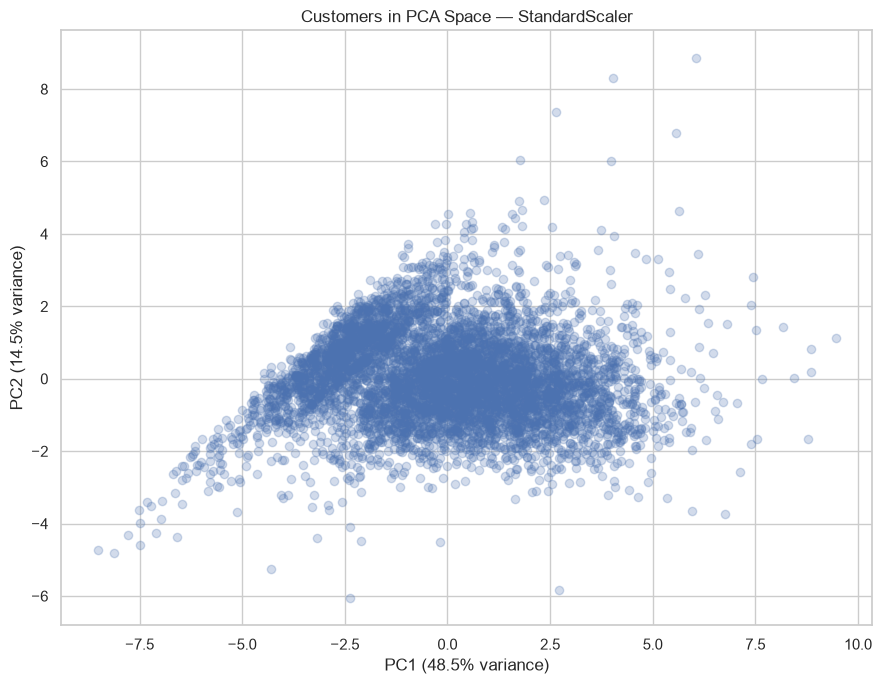

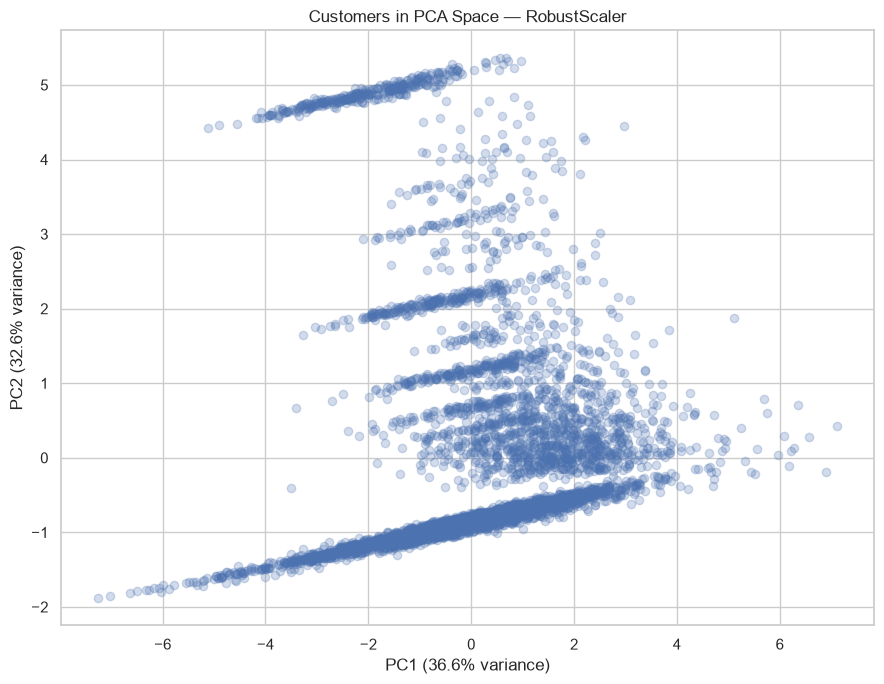

In [18]:
plt.figure(figsize=(9, 7))
plt.scatter(X_standard_pca["PC1"],X_standard_pca["PC2"],alpha=0.25)

plt.xlabel(f"PC1 ({standard_explained[0]:.1%} variance)")
plt.ylabel(f"PC2 ({standard_explained[1]:.1%} variance)")
plt.title("Customers in PCA Space — StandardScaler")

plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 7))
plt.scatter(X_robust_pca["PC1"],X_robust_pca["PC2"],alpha=0.25)

plt.xlabel(f"PC1 ({robust_explained[0]:.1%} variance)")
plt.ylabel(f"PC2 ({robust_explained[1]:.1%} variance)")
plt.title("Customers in PCA Space — RobustScaler")

plt.tight_layout()
plt.show()

### Artifact & Data Persistence

Before moving on to dimensionality reduction (PCA) and clustering, we must save our transformed data and fitted preprocessing pipelines. 

Saving these files ensures our workflow remains modular and deployment-ready:

* **Processed Data (`.csv`):** Save the engineered customer dataset `customer_df` with preserved Customer ID indexing to data/processed/ for downstream modeling and exploratory visual analysis, By exporting `X_standard` and `X_robust` to the `data/processed/` directory, we can load these matrices directly into our next notebook (`04_clustering_experiments.ipynb`) without needing to recalculate the transformations from scratch.
* **Fitted Pipelines (`.joblib`):** Serializing the `preprocessor_standard` and `preprocessor_robust` objects via `joblib` into the `models/` folder locks in the learned parameters (like standard deviations, means, and IQRs). This is critical for production—it allows us to apply the exact same mathematical scaling to new, unseen customer data in the future.

In [19]:
X.to_csv('../data/processed/customer_df.csv', index=True)

X_standard.to_csv('../data/processed/X_standard.csv', index=True)
X_robust.to_csv('../data/processed/X_robust.csv', index=True)

joblib.dump(preprocessor_standard, '../models/preprocessor_standard.joblib')
joblib.dump(preprocessor_robust, '../models/preprocessor_robust.joblib')

print("Successfully saved transformed data to '../data/processed/'")
print("Successfully saved preprocessor models to '../models/'")

Successfully saved transformed data to '../data/processed/'
Successfully saved preprocessor models to '../models/'


### Final Conclusions

The preprocessing analysis showed that the customer behavioral features contain substantial skewness, extreme observations, and several correlated signals.

**Logarithmic and power transformations** were therefore applied to appropriate features before scaling. **StandardScaler and RobustScaler** were evaluated because the dataset contains legitimate but highly extreme customer behaviors.

**The PCA analysis** demonstrates that dimensionality reduction is feasible without retaining all 11 original behavioral features.

**StandardScaler PCA** retains approximately 81% of variance with 4 components and approximately 94% with 6 components.

**RobustScaler PCA** retains approximately 81% of variance with only 3 components and approximately 92% with 5 components.

**RobustScaler PCA** also distributes the variance more evenly across the first two principal components, whereas **StandardScaler PCA** contains a substantially more dominant first component.

However, PCA variance preservation alone does not establish that PCA will produce superior customer segments.

Therefore, the clustering experiments will compare:

- Standard-scaled original feature space.
- Robust-scaled original feature space.
- StandardScaler PCA using a moderate-dimensional representation.
- RobustScaler PCA using a moderate-dimensional representation.

The final representation will be selected from downstream clustering quality, stability, cluster-size behavior, and business interpretability.